# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [62]:
# imports

import os
import json
from dotenv import load_dotenv
from groq import Groq
from openai import OpenAI
import gradio as gr
import sqlite3

In [63]:
# Initialization

load_dotenv(override=True)

groq_api_key = os.getenv('GROQ_API_KEY')
groq_api_model = os.getenv('GROQ_API_MODEL')

openai_api_key = os.getenv('OPENAI_API_KEY')
openai_api_model = os.getenv('OPENAI_API_MODEL')
if groq_api_key:
    print(f"Groq API Key exists and begins {groq_api_key[:8]}")
else:
    print("Groq API Key not set")
    
if groq_api_model:
    print(f"groq_api_model exists  {groq_api_model}")
else:
    print("groq_api_model not set")

if openai_api_key:
    print(f"Openai API Key exists and begins {openai_api_key[:8]}")
else:
    print("Openai API Key not set")

if openai_api_model:
    print(f"openai_api_model exists  {openai_api_model}")
else:
    print("openai_api_model not set")

groq = Groq(api_key=groq_api_key)
openai = OpenAI(api_key=openai_api_key)

DB = "prices.db"

Groq API Key exists and begins gsk_23vF
groq_api_model exists  openai/gpt-oss-120b
Openai API Key exists and begins sk-proj-
openai_api_model exists  gpt-4o-mini


In [64]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [ ]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [66]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


'Ticket price to Paris is $899.0'

In [67]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [68]:

# this is simplve chat function to openai model
def chat(message, history):

    # initial history variable is this
    # 
    #  [
    #   {"role": "user", "content": "Hi", "metadata": None, "options": None},
    #   {"role": "assistant", "content": "Hello!", "metadata": None, "options": None},
    # ] 
    #  and it will be converted into this 
    # [
    #   {"role": "user", "content": "Hi"},
    #   {"role": "assistant", "content": "Hello!"},
    # ]
    #  so in short all attributes except role and content will be removed
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    #  and here we construct a message array  with system message. plus history message to preserve context and new upcoming message
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=openai_api_model, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


In [ ]:
# improvement in above function by adding handle_tool_call which will get called only if travel city is provided on conversation by user
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=openai_api_model, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=openai_api_model, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [70]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [ ]:
gr.ChatInterface(fn=chat, type="messages").launch()

## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this Svelte app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use openai/gpt-oss-120b, the image generation model behind GPT-5, to make us some images

Let's put this in a function called artist.

### Price alert: each time I generate an image it costs about 3 cents - don't go crazy with images!

In [77]:
# Some imports for handling images

import base64
from io import BytesIO
from PIL import Image
load_dotenv(override=True)
openai_api_model_for_image_generation = os.getenv('OPENAI_API_MODEL_FOR_IMAGE_GENERATION')
print(f" model is being used for image generation is>>>>>  {openai_api_model_for_image_generation}")

 model is being used for image generation is>>>>>  gpt-image-1-mini


In [78]:
def artist(city):
    image_response = openai.images.generate(
            model=openai_api_model_for_image_generation,
            prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
            size="1024x1024",
            n=1,
        )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

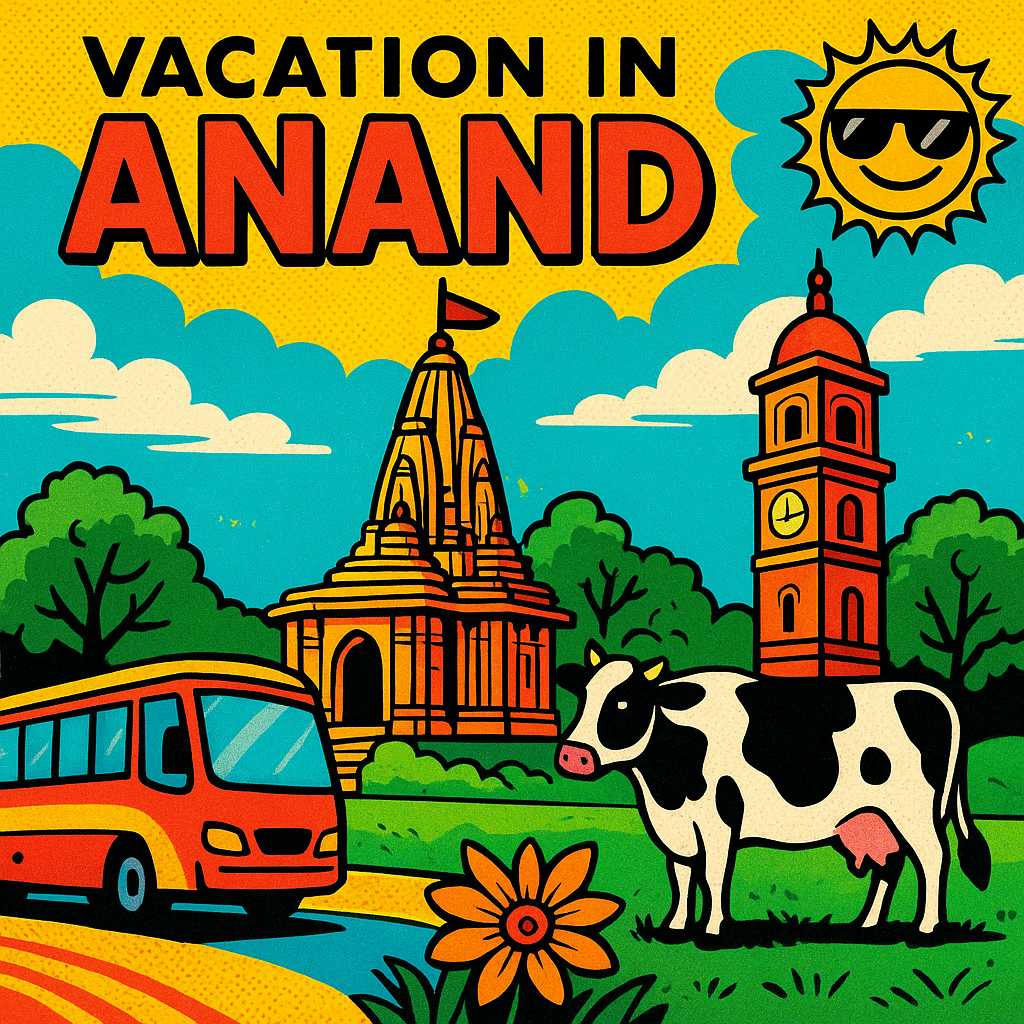

In [80]:
image = artist("anand")
display(image)

In [81]:
load_dotenv(override=True)
openai_api_model_for_audio_speech_generation = os.getenv('OPENAI_API_MODEL_FOR_AUDIO_SPEECH_GENERATION')
print(f" model is being used for image generation is>>>>>  {openai_api_model_for_audio_speech_generation}")

def talker(message):
    response = openai.audio.speech.create(
      model=openai_api_model_for_audio_speech_generation,
      voice="onyx",    # Also, try replacing onyx with alloy or coral
      input=message
    )
    return response.content

 model is being used for image generation is>>>>>  gpt-4o-mini-tts


## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow


In [82]:
def chat(history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=openai_api_model, messages=messages, tools=tools)
    cities = []
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, cities = handle_tool_calls_and_return_cities(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=openai_api_model, messages=messages, tools=tools)

    reply = response.choices[0].message.content
    history += [{"role":"assistant", "content":reply}]

    voice = talker(reply)

    if cities:
        image = artist(cities[0])
    
    return history, voice, image


In [83]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [85]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("mikin", "patel"))

* Running on local URL:  http://127.0.0.1:7867
* To create a public link, set `share=True` in `launch()`.


DATABASE TOOL CALLED: Getting price for Tarapur


# Exercises and Business Applications

Add in more tools - perhaps to simulate actually booking a flight. A student has done this and provided their example in the community contributions folder.

Next: take this and apply it to your business. Make a multi-modal AI assistant with tools that could carry out an activity for your work. A customer support assistant? New employee onboarding assistant? So many possibilities! Also, see the week2 end of week Exercise in the separate Notebook.

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thankyou.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#090;">I have a special request for you</h2>
            <span style="color:#090;">
                My editor tells me that it makes a HUGE difference when students rate this course on Udemy - it's one of the main ways that Udemy decides whether to show it to others. If you're able to take a minute to rate this, I'd be so very grateful! And regardless - always please reach out to me at ed@edwarddonner.com if I can help at any point.
            </span>
        </td>
    </tr>
</table>